In [1]:
# modules
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import h5py
from datetime import datetime, timedelta, timezone
from scipy.signal import welch, hilbert, correlate, spectrogram, resample, decimate
from scipy.optimize import curve_fit
from numpy.fft import rfft, rfftfreq
plt.rcParams['text.usetex']=False

In [2]:
yaw = '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/data/th228_sail/20250827/Y1_RDS-LES_YAW_MON_OUT_DQ_1440410908_1440670108.h5' 
out1 = '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/data/th228_sail/20250827/Y1_RDS-OUTS_V1_MON_OUT_DQ_1440410908_1440670108.h5'
out2 = '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/data/th228_sail/20250827/Y1_RDS-OUTS_V2_MON_OUT_DQ_1440410908_1440670108.h5'
out3 = '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/data/th228_sail/20250827/Y1_RDS-OUTS_V3_MON_OUT_DQ_1440410908_1440670108.h5'
out4 = '/Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/data/th228_sail/20250827/Y1_RDS-OUTS_V4_MON_OUT_DQ_1440410908_1440670108.h5'

filenames = [yaw, out1, out2, out3, out4]


Processing /Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/data/th228_sail/20250827/Y1_RDS-LES_YAW_MON_OUT_DQ_1440410908_1440670108.h5
Total samples: 265420800
Sample rate: 1024.0 Hz
Decimation step: 1327

Processing /Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/data/th228_sail/20250827/Y1_RDS-OUTS_V1_MON_OUT_DQ_1440410908_1440670108.h5
Total samples: 265420800
Sample rate: 1024.0 Hz
Decimation step: 1327

Processing /Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/data/th228_sail/20250827/Y1_RDS-OUTS_V2_MON_OUT_DQ_1440410908_1440670108.h5
Total samples: 265420800
Sample rate: 1024.0 Hz
Decimation step: 1327

Processing /Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/data/th228_sail/20250827/Y1_RDS-OUTS_V3_MON_OUT_DQ_1440410908_1440670108.h5
Total samples: 265420800
Sample rate: 1024.0 Hz
Decimation step: 1327

Processing /Users/mollywatts/Library/CloudStorage/Dropbox/Microspheres/data/th228_sail/20250827/Y1_RDS-OUTS_V4_MON_OUT_DQ_14404

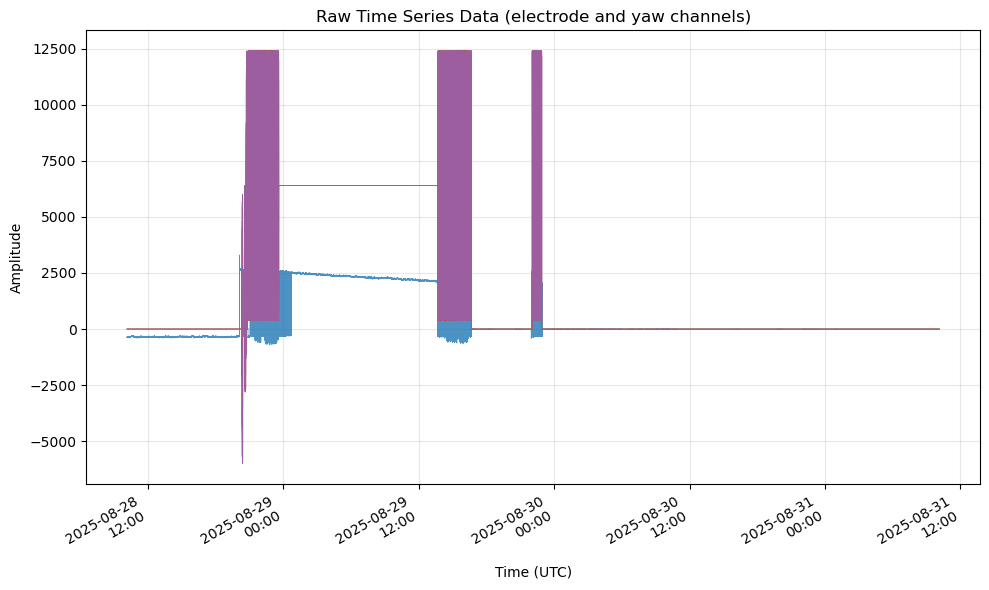

In [3]:
# Plot raw time series data to decide which segments to analyze (not decimated unfortunately)

# constants
max_points = 200_000
GPS_UNIX_OFFSET = 315964800 - 18

plt.figure(figsize=(10, 6))

for filename in filenames:
    with h5py.File(filename, 'r') as f:
        data = f['data']
        segment_starts = f['segments/index_start'][:]
        segment_lengths = f['segments/length'][:]
        gps_times = f['segments/gps_start'][:]
        sample_rate = float(f.attrs['sample_rate'])
        dt = 1.0 / sample_rate

        total_samples = int(data.shape[0])
        step = max(1, total_samples // max_points)

        print(f"\nProcessing {filename}")
        print(f"Total samples: {total_samples}")
        print(f"Sample rate: {sample_rate} Hz")
        print(f"Decimation step: {step}")

        t_plot = []
        y_plot = []

        for i in range(len(segment_starts)):
            start = int(segment_starts[i])
            n = int(segment_lengths[i])
            if n <= 0:
                continue

            r = (-start) % step
            seg_indices = np.arange(start + r, start + n, step, dtype=np.int64)
            if seg_indices.size == 0:
                continue

            y_seg = data[seg_indices]
            t_seg = gps_times[i] + (seg_indices - start).astype(np.float64) * dt

            t_datetime = [
                datetime.fromtimestamp(tt + GPS_UNIX_OFFSET, tz=timezone.utc)
                for tt in t_seg
            ]

            t_plot.extend(t_datetime)
            y_plot.extend(y_seg.astype(np.float32))

        plt.plot(t_plot, y_plot, linewidth=0.6, alpha=0.8, label=filename)

plt.xlabel("Time (UTC)")
plt.ylabel("Amplitude")
plt.title("Raw Time Series Data (electrode and yaw channels)")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
plt.gcf().autofmt_xdate()
plt.grid(True, alpha=0.3)
#plt.legend()
plt.tight_layout()
plt.show()


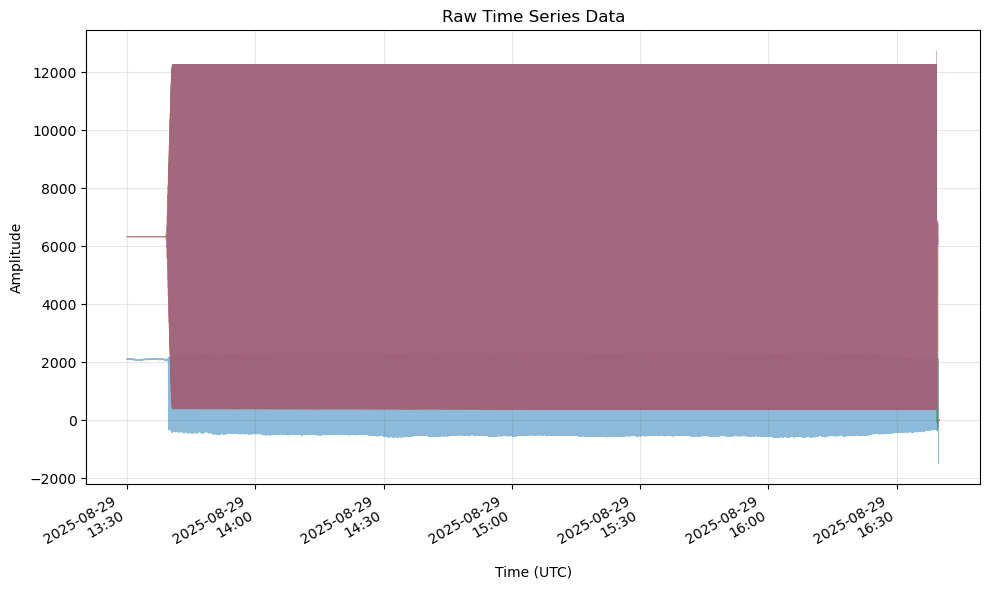

In [ ]:
# applying scipy decimate as a fix; uses chebyshev filter - ONLY works for shorter data sets - work on a better way

# constants
fs_target = 200.0 # choose new target sampling rate (Hz) for downsampling - may be slightly different based on original sample rate
GPS_UNIX_OFFSET = 315964800 - 18

# set expected drive frequency (Hz) if known, else None
expected_drive_freq = None # This is changing so maybe set a list of expected frequencies....?

# define a time window (set to None if not needed)
# start_time = datetime(2025, 8, 28, 21, 3, 0, tzinfo=timezone.utc)
# end_time   = datetime(2025, 8, 28, 21, 4, 30, tzinfo=timezone.utc)
start_time = datetime(2025, 8, 29, 13, 30, 0, tzinfo=timezone.utc)
end_time = datetime(2025, 8, 29, 16, 45, 0, tzinfo=timezone.utc)

plt.figure(figsize=(10, 6))

for filename in filenames:
    with h5py.File(filename, "r") as f:
        data = f["data"]
        segment_starts = f["segments/index_start"][:]
        segment_lengths = f["segments/length"][:]
        gps_times = f["segments/gps_start"][:]
        sample_rate = float(f.attrs["sample_rate"])
        dt = 1.0 / sample_rate

        total_samples = int(data.shape[0])

        # Collect full arrays 
        t_full = []
        y_full = []
        for i in range(len(segment_starts)):
            start = int(segment_starts[i])
            n = int(segment_lengths[i])
            if n <= 0:
                continue

            y_seg = data[start:start+n]
            t_seg = gps_times[i] + np.arange(n) * dt
            t_full.append(t_seg)
            y_full.append(y_seg)

        if not t_full:
            continue

        t_full = np.concatenate(t_full)
        y_full = np.concatenate(y_full)

        # Apply the time window 
        if start_time and end_time:
            t_start = (start_time.timestamp() - GPS_UNIX_OFFSET)
            t_end   = (end_time.timestamp()   - GPS_UNIX_OFFSET)
            mask = (t_full >= t_start) & (t_full <= t_end)
            t_full = t_full[mask]
            y_full = y_full[mask]

        if len(y_full) == 0:
            continue

        q = max(1, int(sample_rate / fs_target)) # downsampling factor from target sampling rate
        fs_effective = sample_rate / q # effective sampling rate after downsampling
        y_ds = decimate(y_full, q, ftype="iir", zero_phase=True) # use decimate with cheby filter
        t_ds = t_full[::q] # this is off by 1...?

        # Aliasing safety check!! 
        nyquist = fs_effective / 2 # Nyquist frequency is half the sampling rate
        if expected_drive_freq and expected_drive_freq > nyquist:
            print(f"WARNING: {filename} — Expected drive {expected_drive_freq:.2f} Hz "
                    f"is above Nyquist {nyquist:.2f} Hz (aliasing risk).")

        # Convert times to datetimes
        t_plot = [datetime.fromtimestamp(tt + GPS_UNIX_OFFSET, tz=timezone.utc)
                  for tt in t_ds]

        plt.plot(t_plot, y_ds, linewidth=0.6, alpha=0.5, label=filename)

plt.xlabel("Time (UTC)")
plt.ylabel("Amplitude")
plt.title(f"Raw Time Series Data")
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
plt.gcf().autofmt_xdate()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Import & concatenate all data files into a dictionary
keys = ["yaw", "out1", "out2", "out3", "out4"] # keys for dictionary related to filenames
data_dict = {}

for key, fname in zip(keys, filenames):
    with h5py.File(fname, "r") as f:
        data = f["data"][:]
        segment_starts = f["segments/index_start"][:]
        segment_lengths = f["segments/length"][:]
        gps_times = f["segments/gps_start"][:]
        sample_rate = float(f.attrs["sample_rate"])
        dt = 1.0 / sample_rate

    # convert gps to unix time
    unix_times = gps_times + GPS_UNIX_OFFSET

    full = []
    for start, n in zip(segment_starts, segment_lengths):
        if n > 0:
            full.append(data[int(start):int(start)+int(n)])

    concat = np.concatenate(full)
    data_dict[key] = {
        "data": concat,
        "unix_times": unix_times,
        "segment_lengths": segment_lengths,
        "sample_rate": sample_rate,
        "dt": dt
    }
    print(f"Length {key} data: {len(concat)}")

Length yaw data: 265420800
Length out1 data: 265420800
Length out2 data: 265420800
Length out3 data: 265420800
Length out4 data: 265420800


In [ ]:
# time window for analysis

start_time = datetime(2025, 8, 29, 13, 30, 0, tzinfo=timezone.utc)
end_time   = datetime(2025, 8, 29, 16, 45, 0, tzinfo=timezone.utc)
t0 = start_time.timestamp()
t1 = end_time.timestamp()

# Build time vectors and windowed data for each key
windowed = {}
for key in ["yaw", "out1", "out2", "out3", "out4"]:
    x   = data_dict[key]["data"]
    fs  = float(data_dict[key]["sample_rate"])
    n_s = np.asarray(data_dict[key]["segment_lengths"], dtype=int)
    u_t = np.asarray(data_dict[key]["unix_times"], dtype=float)  # unix_times

    # Absolute Unix time per sample
    t = np.concatenate([t0u + np.arange(n, dtype=float)/fs
                        for t0u, n in zip(u_t, n_s) if n > 0])

    m = (t >= t0) & (t <= t1)
    windowed[key] = {"t": t[m], "x": x[m], "fs": fs}

# Sanity check lengths match across keys 
print({k: len(windowed[k]["x"]) for k in windowed})

{'yaw': 11980801, 'out1': 11980801, 'out2': 11980801, 'out3': 11980801, 'out4': 11980801}


/var/folders/pm/q9m_8qtd49d0qpf2b6nzw89h0000gn/T/ipykernel_5438/3738846069.py:9: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


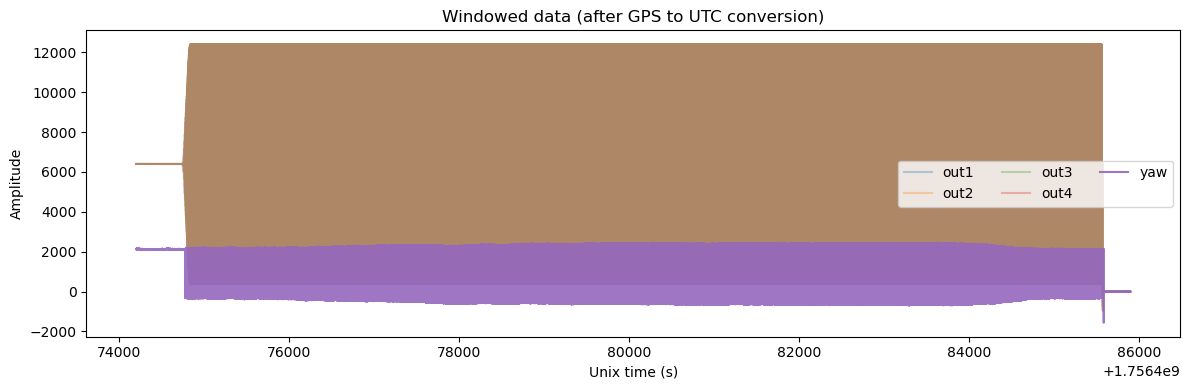

In [ ]:
# Plotting windowed data sanity check

plt.figure(figsize=(12,4))
for k in ["out1","out2","out3","out4"]:
    plt.plot(windowed[k]["t"], windowed[k]["x"], alpha=0.3, label=k)
plt.plot(windowed["yaw"]["t"], windowed["yaw"]["x"], alpha=0.9, label="yaw")
plt.xlabel("Unix time (s)")
plt.ylabel("Amplitude")
plt.title("Windowed data (after GPS to UTC conversion)")
plt.legend(ncols=3)
plt.tight_layout()
plt.show()

In [15]:
# choose a 60 s slice at the window start
fft_secs = 60.0
fs = float(windowed["out1"]["fs"])
Nwin = int(round(fft_secs * fs))
#assert Nwin < len(windowed["out1"]["x"]), "Not enough samples for the chosen fft_secs."

start_idx = 0
stop_idx  = start_idx + Nwin

# Hann window
w = np.hanning(Nwin)

# rFFT for each channel over this slice
X_raw = {}
freqs = None
for k in ["yaw","out1","out2","out3","out4"]:
    xseg = windowed[k]["x"][start_idx:stop_idx] * w
    X_raw[k] = np.fft.rfft(xseg)
    if freqs is None:
        freqs = np.fft.rfftfreq(len(xseg), d=1.0/fs)

# Amplitude spectra
amp_raw = {k: np.abs(X_raw[k]) for k in X_raw}

# Compare DC vs. the max above 0.5 Hz
for k in ["out1","out2","out3","out4","yaw"]:
    dc = amp_raw[k][0]
    mask = freqs > 0.5
    mx  = amp_raw[k][mask].max()
    print(f"{k:>4}: DC={dc:.3e}, max(>0.5Hz)={mx:.3e}, ratio={dc/mx:.1f}x")

# # Plot amplitude spectra (start slice)
# plt.figure(figsize=(10,5))
# for k in ["out1","out2","out3","out4"]:
#     plt.plot(freqs, amp_raw[k], alpha=0.7, lw=1.0, label=k)
# plt.plot(freqs, amp["yaw"], alpha=0.9, lw=1.2, label="yaw", color="k")
# plt.xlim(0, freqs[-1]/4)  # zoom if needed
# plt.xlabel("Frequency (Hz)")
# plt.ylabel("|X(f)|")
# plt.title(f"Amplitude spectra (first {fft_secs:.0f} s of window)")
# plt.legend()
# plt.tight_layout()
# plt.show()

out1: DC=1.966e+08, max(>0.5Hz)=3.333e+00, ratio=58979542.7x
out2: DC=1.966e+08, max(>0.5Hz)=3.333e+00, ratio=58979542.7x
out3: DC=1.966e+08, max(>0.5Hz)=3.333e+00, ratio=58979542.7x
out4: DC=1.966e+08, max(>0.5Hz)=3.333e+00, ratio=58979542.7x
 yaw: DC=6.563e+07, max(>0.5Hz)=9.341e+03, ratio=7026.5x


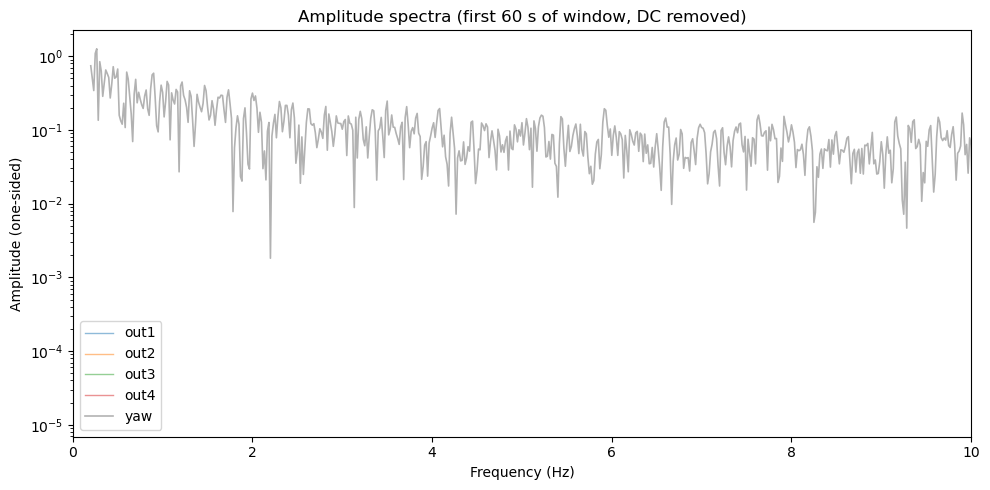

In [19]:
w = np.hanning(Nwin)
coherent_gain = w.sum() / Nwin  # Hann ≈ 0.5

X = {}
freqs = None
for k in ["yaw","out1","out2","out3","out4"]:
    xseg = windowed[k]["x"][start_idx:stop_idx].astype(float)
    xseg -= xseg.mean() # remove DC offset
    xw = xseg * w
    X[k] = np.fft.rfft(xw)
    if freqs is None:
        freqs = np.fft.rfftfreq(len(xw), d=1.0/fs)

# Amplitude normalization (one-sided)
amp = {}
for k in X:
    A = np.abs(X[k]) / (Nwin * coherent_gain)  # scale by N and window coherent gain
    if len(A) > 1:
        A[1:-1] *= 2.0                        # one-sided correction (except DC & Nyquist)
    amp[k] = A

# Plot, excluding DC and using log scale (helps dynamic range)
fmin = 0.2          # ignore <0.2 Hz
mask = freqs >= fmin

plt.figure(figsize=(10,5))
for k in ["out1","out2","out3","out4"]:
    plt.semilogy(freqs[mask], amp[k][mask], alpha=0.5, lw=1.0, label=k)
plt.semilogy(freqs[mask], amp["yaw"][mask], alpha=0.3, lw=1.2, color="k", label="yaw")
plt.xlim(0,10)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude (one-sided)")
plt.title(f"Amplitude spectra (first {fft_secs:.0f} s of window, DC removed)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# parameters
# start_time = datetime(2025, 8, 28, 21, 0, 0, tzinfo=timezone.utc)
# end_time = datetime(2025, 8, 29, 1, 0, 0, tzinfo=timezone.utc)
print('time window set UTC')

# change to seconds
start_sec = start_time.timestamp() - GPS_UNIX_OFFSET
end_sec = end_time.timestamp() - GPS_UNIX_OFFSET

# Build time axis from yaw (reference channel)
gps_times = data_dict["yaw"]["gps_times"]
dt = data_dict["yaw"]["dt"]
yaw_len = len(data_dict["yaw"]["data"])
t_abs = gps_times[0] + np.arange(yaw_len) * dt

# apply mask
mask = (t_abs >= start_sec) & (t_abs <= end_sec)

# apply mask to all arrays in dictionary
for key, entry in data_dict.items():
    entry["data"] = entry["data"][mask]
    print(f"Length {key} data after mask: {len(entry['data'])}")

# define relative time axis
t = t_abs[mask] - t_abs[mask][0]
print('mask complete')

# update dt and fs based on masked data
dt = np.median(np.diff(t))
fs = 1.0 / dt
window_length = 60  # seconds per FFT window
nperseg = int(window_length * fs)
print('Number of samples per segment (nperseg):', nperseg)

time window set UTC
Length yaw data after mask: 0
Length out1 data after mask: 0
Length out2 data after mask: 0
Length out3 data after mask: 0
Length out4 data after mask: 0


IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
# parameters
# time window for analysis in UTC

start_time = datetime(2025, 8, 28, 21, 0, 0, tzinfo=timezone.utc)
end_time = datetime(2025, 8, 29, 1, 0, tzinfo=timezone.utc)
print('time window set UTC')

# change to seconds
start_sec = start_time.timestamp() - GPS_UNIX_OFFSET
end_sec = end_time.timestamp() - GPS_UNIX_OFFSET

t_abs = gps_times[0] + np.arange(len(yaw)) * dt

# apply mask to data to select time window
mask = (t_abs >= start_sec) & (t_abs <= end_sec)
yaw = yaw[mask]
print('Length yaw data after mask: ', len(yaw))
out1 = out1[mask]
t = t_abs[mask] - t_abs[mask][0]  # reset to relative seconds from window start
print('mask complete')

#t = np.arange(len(yaw)) * dt
dt = np.median(np.diff(t)) # sampling interval (s) - taking median instead of first element to be more robust to outliers
fs = 1.0 / dt # sampling rate (Hz)

window_length = 100 # window length (seconds per FFT window)
nperseg = int(window_length * fs) # number of samples per segment -- may need to change
print('Number of samples per segment (nperseg):', nperseg)

time window set UTC
Length yaw data after mask:  14745601
mask complete
Number of samples per segment (nperseg): 102400


In [6]:
# lock-in analysis - looking at frequency (using rfft) and if sample and electrodes are in phase
# import & concat data 

# sample
yaw_file = filenames[0] 

with h5py.File(yaw_file, "r") as f:
    data = f["data"][:] # full raw samples
    segment_starts = f["segments/index_start"][:]
    segment_lengths = f["segments/length"][:]
    gps_times = f["segments/gps_start"][:]
    sample_rate = float(f.attrs["sample_rate"])
    dt = 1.0 / sample_rate

# concatenate
yaw_full = []
for i in range(len(segment_starts)):
    start = int(segment_starts[i])
    n = int(segment_lengths[i])
    if n <= 0:
        continue
    yaw_full.append(data[start:start+n])

yaw = np.concatenate(yaw_full)
print('Length yaw data: ', len(yaw))

# out1 to start
out1_file = filenames[1]

with h5py.File(out1_file, "r") as f:
    data = f["data"][:] # full raw samples
    segment_starts = f["segments/index_start"][:]
    segment_lengths = f["segments/length"][:]
    gps_times = f["segments/gps_start"][:]
    sample_rate = float(f.attrs["sample_rate"])
    dt = 1.0 / sample_rate

# concatenate all segments
out1_full = []
for i in range(len(segment_starts)):
    start = int(segment_starts[i])
    n = int(segment_lengths[i])
    if n <= 0:
        continue
    out1_full.append(data[start:start+n])

out1 = np.concatenate(out1_full)

Length yaw data:  265420800


In [13]:
start_time = datetime(2025, 8, 28, 21, 0, 0, tzinfo=timezone.utc)
end_time   = datetime(2025, 8, 29, 1, 0, tzinfo=timezone.utc)

start_sec = start_time.timestamp() - GPS_UNIX_OFFSET
end_sec   = end_time.timestamp()   - GPS_UNIX_OFFSET

# absolute time for this stream
t_abs = gps_times[0] + np.arange(len(yaw)) * dt  # dt is 1/sample_rate

mask = (t_abs >= start_sec) & (t_abs <= end_sec)

# apply the SAME mask to ALL channels
yaw  = yaw[mask]
out1 = out1[mask]   # 0°
out2 = out2[mask]   # 90°
out3 = out3[mask]   # 180°
out4 = out4[mask]   # 270°
t  = t_abs[mask] - t_abs[mask][0]  # relative seconds

# recompute dt, fs from masked data (robust)
dt = np.median(np.diff(t))
fs = 1.0 / dt

TypeError: only integer scalar arrays can be converted to a scalar index

In [ ]:
# --- Quadrature lock-in using out1..out4 ---
from scipy.signal import hilbert, firwin, filtfilt
import numpy as np
import matplotlib.pyplot as plt
import math

# 1) DC remove
yaw  = yaw  - np.mean(yaw)
out1 = out1 - np.mean(out1)
out2 = out2 - np.mean(out2)
out3 = out3 - np.mean(out3)
out4 = out4 - np.mean(out4)

# 2) Build complex reference and normalize
ref_cos = out1 - out3          # 0° – 180°
ref_sin = out2 - out4          # 90° – 270°
s_ref   = ref_cos + 1j*ref_sin
s_ref  /= np.maximum(np.abs(s_ref), 1e-12)

# 3) Demodulate yaw
y_a  = hilbert(yaw)
z_bp = y_a * np.conj(s_ref)    # baseband (I/Q)

# 4) Low-pass (lock-in time constant)
tau = 5.0                      # seconds (tune 2–10 s)
fc  = min(1.0/(2*math.pi*tau), 0.45*fs)
taps = int(min(max(int(fs*2*tau), 101), 20001))
if taps % 2 == 0: taps += 1
b = firwin(taps, fc/(fs/2))
z = filtfilt(b, [1.0], z_bp)

I = np.real(z)
Q = np.imag(z)
R = np.hypot(I, Q)
phi = np.unwrap(np.angle(z))
f_beat = np.gradient(phi, dt)/(2*np.pi)

# 5) Plots
fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
ax[0].plot(t, R, lw=0.8);             ax[0].set_ylabel('R (arb)'); ax[0].set_title('Lock-in amplitude')
ax[1].plot(t, phi, lw=0.8);           ax[1].set_ylabel('Phase (rad)'); ax[1].set_title('Lock-in phase (yaw vs ref)')
ax[2].plot(t, f_beat, lw=0.8); ax[2].axhline(0, ls='--', lw=0.8)
ax[2].set_ylabel('Beat freq (Hz)');   ax[2].set_xlabel('Time (s)'); ax[2].set_title('Instantaneous beat frequency')
plt.tight_layout(); plt.show()

In [7]:
yaw_analytic = hilbert(yaw)
print('yaw_analytic complete')
out1_analytic = hilbert(out1)
print('out1_analytic complete')

yaw_phase = np.unwrap(np.angle(yaw_analytic))
out1_phase = np.unwrap(np.angle(out1_analytic))

phase_diff = np.mod(yaw_phase - out1_phase, 2*np.pi)  # wrapped 0–2pi
yaw_amp = np.abs(yaw_analytic)

# instantaneous frequency (optional, Hz)
yaw_freq_inst = np.diff(yaw_phase) / (2*np.pi*dt)
out1_freq_inst = np.diff(out1_phase) / (2*np.pi*dt)

yaw_analytic complete
out1_analytic complete


/var/folders/pm/q9m_8qtd49d0qpf2b6nzw89h0000gn/T/ipykernel_1166/2484119929.py:75: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/mollywatts/opt/anaconda3/envs/decay_sail_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


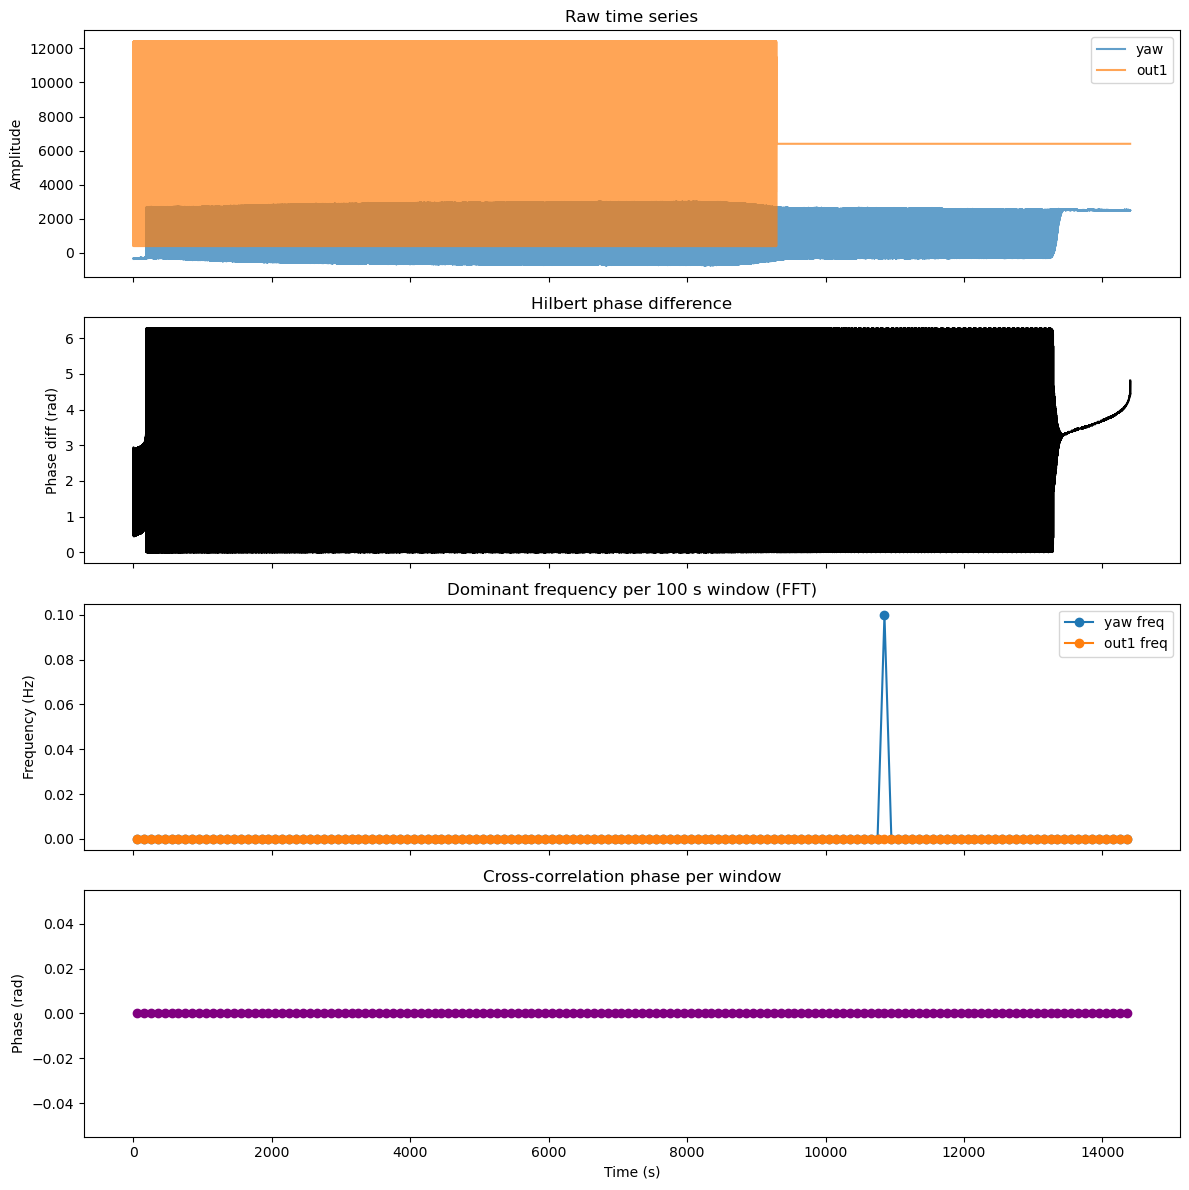

In [ ]:
step_samples = int(window_length * fs)
n_windows = len(yaw) // step_samples
fft_times, yaw_freqs, out1_freqs = [], [], []

for w in range(n_windows):
    start = w*step_samples
    stop = start+step_samples
    if stop > len(yaw): break

    seg_yaw = yaw[start:stop]
    seg_out1 = out1[start:stop]

    # FFT
    Y = np.abs(rfft(seg_yaw))
    O = np.abs(rfft(seg_out1))
    freqs = rfftfreq(len(seg_yaw), dt)

    yaw_freqs.append(freqs[np.argmax(Y)])
    out1_freqs.append(freqs[np.argmax(O)])
    fft_times.append(t[start + step_samples//2])

fft_times = np.array(fft_times)

# --- 3. Cross-correlation phase offset (per window) ---
xcorr_phase = []
for w in range(n_windows):
    start = w*step_samples
    stop = start+step_samples
    if stop > len(yaw): break

    seg_yaw = yaw[start:stop]
    seg_out1 = out1[start:stop]

    corr = correlate(seg_yaw - np.mean(seg_yaw), seg_out1 - np.mean(seg_out1), mode='full')
    lag = np.argmax(corr) - (len(seg_yaw)-1)
    lag_time = lag * dt

    # convert lag to phase at dominant out1 frequency
    phase_est = (2*np.pi*lag_time*out1_freqs[w]) % (2*np.pi)
    xcorr_phase.append(phase_est)

xcorr_phase = np.array(xcorr_phase)

# --- 4. Spectrogram (optional) ---
f_spec, t_spec, Sxx = spectrogram(yaw, fs=fs, nperseg=nperseg, noverlap=nperseg//2)

# --- Plotting ---
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

# (a) Raw data
axes[0].plot(t, yaw, label="yaw", alpha=0.7)
axes[0].plot(t, out1, label="out1", alpha=0.7)
axes[0].set_ylabel("Amplitude")
axes[0].legend()
axes[0].set_title("Raw time series")

# (b) Hilbert phase difference
axes[1].plot(t, phase_diff, color='k')
axes[1].set_ylabel("Phase diff (rad)")
axes[1].set_title("Hilbert phase difference")

# (c) FFT frequency vs time
axes[2].plot(fft_times, yaw_freqs, 'o-', label="yaw freq")
axes[2].plot(fft_times, out1_freqs, 'o-', label="out1 freq")
axes[2].set_ylabel("Frequency (Hz)")
axes[2].legend()
axes[2].set_title("Dominant frequency per 100 s window (FFT)")

# (d) Cross-correlation phase estimate
axes[3].plot(fft_times, xcorr_phase, 'o-', color='purple')
axes[3].set_ylabel("Phase (rad)")
axes[3].set_title("Cross-correlation phase per window")
axes[3].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

# # --- Optional: Spectrogram (separate figure) ---
# plt.figure(figsize=(10,5))
# plt.pcolormesh(t_spec, f_spec, 10*np.log10(Sxx), shading='gouraud')
# plt.colorbar(label="Power [dB]")
# plt.ylabel("Frequency [Hz]")
# plt.xlabel("Time [s]")
# plt.title("Yaw spectrogram")
# plt.ylim(0, 5)  # zoom near drive range
# plt.show()

In [12]:
from scipy.signal import hilbert

def get_phase_and_freq(y, dt):
    analytic = hilbert(y)
    phase = np.unwrap(np.angle(analytic))
    freq = np.gradient(phase) / (2*np.pi*dt)
    return phase, freq

In [13]:
plt.figure(figsize=(10,6))
plt.plot(t_yaw, freq_yaw, label="Sample (yaw)")
plt.plot(t_out1, freq_out1, label="Electrode (out1)")
plt.xlabel("Time (UTC)")
plt.ylabel("Frequency [Hz]")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,6))
plt.plot(t_yaw, phi_yaw - phi_out1)
plt.xlabel("Time (UTC)")
plt.ylabel("Phase difference [rad]")
plt.title("Phase difference (yaw - out1)")
plt.grid(True)
plt.show()

NameError: name 't_yaw' is not defined

<Figure size 1000x600 with 0 Axes>